In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

In [3]:
# --- Caricamento del grafo ---
# Il file SNAP ha righe "commento" che iniziano con '#', networkx le ignora di default
# con questo formato edge-list.
G = nx.read_edgelist("data/CA-AstroPh.txt", comments="#", nodetype=int)

print(f"Numero di nodi: {G.number_of_nodes()}")
print(f"Numero di archi: {G.number_of_edges()}")


Numero di nodi: 18772
Numero di archi: 198110


In [5]:
# --- Componente connessa più grande ---
largest_cc = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc).copy()
print(f"Nodi nella componente connessa più grande: {G_lcc.number_of_nodes()} "
      f"({G_lcc.number_of_nodes() / G.number_of_nodes():.3%})")
print(f"Archi nella componente connessa più grande: {G_lcc.number_of_edges()} "
      f"({G_lcc.number_of_edges() / G.number_of_edges():.3%})")
# --- Gradi ---
degrees = dict(G.degree())
max_degree = max(degrees.values())
avg_degree = 2 * G.number_of_edges() / G.number_of_nodes()
print(f"Grado massimo: {max_degree}")
print(f"Grado medio: {avg_degree:.2f}")

# --- Triangoli e clustering ---
triangles_per_node = nx.triangles(G)
total_triangles = sum(triangles_per_node.values()) // 3  # ogni triangolo contato 3 volte
avg_clustering = nx.average_clustering(G)
print(f"Numero di triangoli: {total_triangles}")
print(f"Coefficiente di clustering medio: {avg_clustering:.4f}")

Nodi nella componente connessa più grande: 17903 (95.371%)
Archi nella componente connessa più grande: 197031 (99.455%)
Grado massimo: 504
Grado medio: 21.11
Numero di triangoli: 1351441
Coefficiente di clustering medio: 0.6306


In [6]:
# --- Diametro (ATTENZIONE: costoso su reti grandi, calcolarlo sulla LCC) ---
# Su reti di questa dimensione, il diametro esatto può richiedere tempo.
# In alternativa si può stimare il diametro effettivo (90-percentile) via
# approssimazione BFS su un campione di nodi.
diameter = nx.diameter(G_lcc)  # decommentare se si vuole il valore esatto (lento)
print(f"Diametro: {diameter}")

Diametro: 14


In [9]:
# Alternativa veloce a nx.diameter(G_lcc), che è troppo lenta su reti di questa dimensione.
# Usa un'approssimazione (algoritmo "double sweep" / euristica), molto più rapida.
 
from networkx.algorithms.approximation import diameter as approx_diameter
 
d = approx_diameter(G_lcc)
print(f"Diametro approssimato: {d}")
 
# In alternativa, per stimare il diametro EFFETTIVO al 90-percentile
# (come riportato dalla pagina SNAP), si può campionare un sottoinsieme di nodi
# sorgente invece di farli tutti, e prendere il percentile delle distanze osservate:
 
import random
import numpy as np
 
random.seed(42)
sample_nodes = random.sample(list(G_lcc.nodes()), k=500)  # campione di 500 nodi sorgente
 
all_distances = []
for node in sample_nodes:
    lengths = nx.single_source_shortest_path_length(G_lcc, node)
    all_distances.extend(lengths.values())
 
effective_diameter_90 = np.percentile(all_distances, 90)
print(f"Diametro effettivo stimato (90-percentile, campione di {len(sample_nodes)} nodi): "
      f"{effective_diameter_90:.1f}")

Diametro approssimato: 14
Diametro effettivo stimato (90-percentile, campione di 500 nodi): 5.0


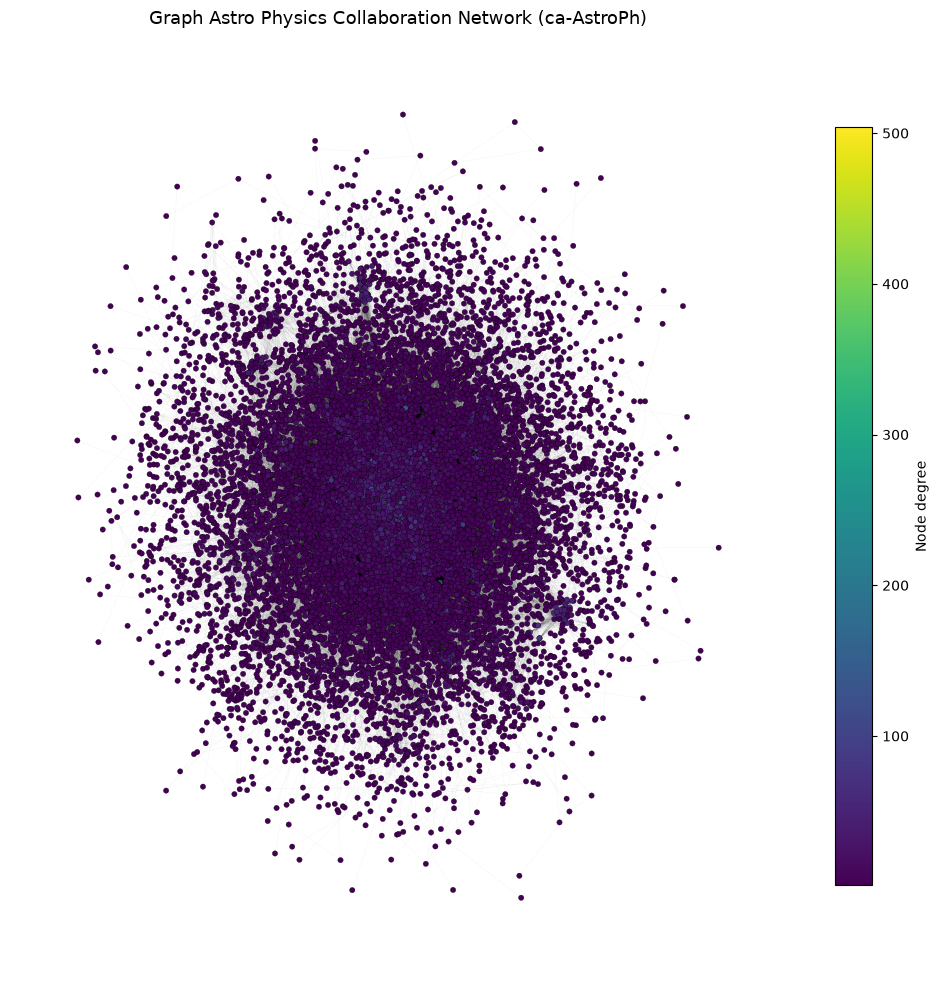

In [8]:
# --- Plot della rete colorata per grado ---
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G_lcc, seed=42, k=0.15, iterations=20)

node_degrees = [degrees[n] for n in G_lcc.nodes()]

nodes = nx.draw_networkx_nodes(
    G_lcc, pos,
    node_size=15,
    node_color=node_degrees,
    cmap=cm.viridis,
    linewidths=0.2,
    edgecolors="black",
)
nx.draw_networkx_edges(G_lcc, pos, alpha=0.05, width=0.3)

plt.colorbar(nodes, label="Node degree", shrink=0.8)
plt.title("Graph Astro Physics Collaboration Network (ca-AstroPh)", fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.savefig("ca_astroph_plot.png", dpi=300)
plt.show()